# FLS: training data audit

Inspect the pinned FinanceMTEB/FLS training split before preparing development
partitions. The audit covers schema, labels, text quality, class balance, lengths,
duplicates, and a reproducible sample for qualitative review.

The published test file is not opened. Source files remain unchanged; findings
are review candidates, not automatic cleaning or relabeling rules. Dataset
provenance and annotation limitations are documented in [data/README.md](../data/README.md).

## Reproduce

From the repository root, install the locked environment and download the pinned
snapshot if it is not already present:

```bash
uv sync --locked --extra data --group notebooks
uv run --no-sync filing-sentence-classifier download-data
```

Select the repository's `.venv` interpreter and run all cells, or execute with:

```bash
uv run --no-sync jupyter execute notebooks/01_data_exploration.ipynb --inplace
```

The notebook works with a working directory at the repository root or inside
`notebooks/`. `RAW_DIR` below can point to another download directory.
`source_row` is a zero-based position in this pinned training file, not a document ID.

In [1]:
import hashlib
import platform
from collections import Counter
from dataclasses import asdict
from importlib.metadata import version
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from filing_sentence_classifier.data.audit import (
    audit_records,
    normalize_duplicate_text,
)
from filing_sentence_classifier.data.fls import FLS_SOURCE, LABEL_NAMES

SEED = 2026
ROOT = next(
    parent
    for parent in (Path.cwd(), *Path.cwd().parents)
    if (parent / "pyproject.toml").is_file() and (parent / "data/README.md").is_file()
)
RAW_DIR = ROOT / "data/raw"
plt.rcParams.update(
    {"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False}
)

In [2]:
train_files = [file for file in FLS_SOURCE.files if file.path.startswith("data/train-")]
assert len(train_files) == 1, "Review the loader if the source gains training shards."
train_file = train_files[0]
train_path = RAW_DIR / FLS_SOURCE.revision / train_file.path
if not train_path.is_file():
    raise FileNotFoundError("Training snapshot is missing; run download-data first.")

train_sha256 = hashlib.sha256(train_path.read_bytes()).hexdigest()
assert train_path.stat().st_size == train_file.size_bytes, (
    "Unexpected training file size."
)
assert train_sha256 == train_file.sha256, "Training checksum does not match the source."

frame = pd.read_parquet(train_path, engine="pyarrow")
frame.insert(0, "source_row", range(len(frame)))
provenance = {
    "dataset": FLS_SOURCE.repo_id,
    "revision": FLS_SOURCE.revision,
    "file": train_file.path,
    "sha256": train_sha256,
    "sample_seed": SEED,
    "python": platform.python_version(),
    **{name: version(name) for name in ("pandas", "pyarrow", "matplotlib", "numpy")},
}
display(pd.Series(provenance, name="value").to_frame())

,value
dataset,FinanceMTEB/FLS
revision,39b6719f1d7197df4498fea9fce20d4ad782a083
file,data/train-00000-of-00001.parquet
sha256,b8eace45f565497fb57740a15d8b72eeee00cf03d878f2...
sample_seed,2026
python,3.13.9
pandas,3.0.5
pyarrow,25.0.1
matplotlib,3.11.2
numpy,2.5.3


## Schema and record quality

Reusable checks live in `filing_sentence_classifier.data.audit`. They accept
Python records, have no dependency on Pandas or FLS, and report source positions.
Warnings flag text for inspection; errors indicate an invalid field.

In [3]:
expected_columns = {"text", "label", "label_text"}
source_columns = set(frame.columns) - {"source_row"}
display(
    pd.DataFrame(
        {
            "dtype": frame[
                list(sorted(expected_columns & source_columns))
            ].dtypes.astype(str),
            "nulls": frame[list(sorted(expected_columns & source_columns))]
            .isna()
            .sum(),
        }
    )
)
print(f"Rows: {len(frame):,} (publisher metadata: 2,600)")
print(f"Missing columns: {sorted(expected_columns - source_columns)}")
print(f"Unexpected columns: {sorted(source_columns - expected_columns)}")
assert source_columns == expected_columns, "Review the source schema before continuing."

# Convert Pandas null sentinels to the audit module's Python scalar contract.
records = frame.astype(object).where(frame.notna(), None).to_dict("records")
report = audit_records(records, LABEL_NAMES)
issues = pd.DataFrame(
    [asdict(issue) for issue in report.issues],
    columns=["row", "field", "code", "severity"],
)
print(f"Rows with errors: {len(report.invalid_rows):,}")
display(
    issues.groupby(["severity", "field", "code"]).size().rename("findings").to_frame()
)

,dtype,nulls
label,int64,0
label_text,str,0
text,str,0


Rows: 2,600 (publisher metadata: 2,600)
Missing columns: []
Unexpected columns: []
Rows with errors: 0


,,,findings
severity,field,code,
warning,text,suspicious_unicode,135


There are no missing values, empty texts, invalid labels, or disagreements between
`label` and `label_text`. However, 135 rows contain C1 control characters. Some
occur where apostrophes, quotation marks, or dashes would be expected, suggesting
an encoding issue. This is a hypothesis to verify before applying a targeted repair.

In [4]:
unicode_rows = issues.loc[issues["code"] == "suspicious_unicode", "row"].tolist()
suspicious_chars = Counter(
    char
    for text in frame["text"]
    for char in text
    if "\u0080" <= char <= "\u009f" or char == "\ufffd"
)
display(
    pd.DataFrame(
        [
            {"codepoint": f"U+{ord(char):04X}", "occurrences": count}
            for char, count in sorted(suspicious_chars.items())
        ]
    )
)
print(f"Flagged rows: {len(unicode_rows):,} ({len(unicode_rows) / len(frame):.2%})")
unicode_examples = frame.loc[
    unicode_rows[:5], ["source_row", "label_text", "text"]
].copy()
unicode_examples["text"] = unicode_examples["text"].map(
    lambda text: text.encode("unicode_escape").decode("ascii")
)
with pd.option_context("display.max_colwidth", None):
    display(unicode_examples)

,codepoint,occurrences
0,U+0092,120
1,U+0093,46
2,U+0094,50
3,U+0095,4
4,U+0096,2
5,U+0097,5


Flagged rows: 135 (5.19%)


,source_row,label_text,text
61,61,not-fls,"Assigned capital \x96 Capital assignments based on management\x92s assessment of inherent risks and equity levels at independent companies providing similar products and services in order to present, to the extent practicable, the financial results of each business as if it operated on a stand-alone basis."
89,89,not-fls,"Included within the purchase obligations amount in the table above are annual commitments of approximately $29.7 million relating to the Company\x92s natural gas distribution and production operations for demand charges under existing long-term contracts with pipeline suppliers for periods extending up to eleven years at December 31, 2004."
99,99,not-fls,"Moreover, most of the Company\x92s senior notes and debentures contain cross-default provisions based on the non-payment at maturity, or other default after an applicable grace period, of any other debt, the unpaid principal amount of which is not less than $100 million, that could be triggered by an event of default under the credit agreement."
121,121,not-fls,"As of December 31, 2009, 156 of the Company\x92s employees were represented by labor unions."
123,123,non-specific fls,"Governmental regulatory authorities have required, and may require in the future, that certain scientific data requirements be performed on the Company\x92s products."


## Class balance

`not-fls` accounts for 52.69% of the training rows; `specific fls` is the smallest
class at 16.38%. This supports reporting macro-F1 and per-class metrics alongside
accuracy. A majority-class predictor would reach 52.69% accuracy on these rows;
this is descriptive, not a held-out evaluation result.

,label_text,rows,percent
label,,,
0,specific fls,426,16.38
1,not-fls,1370,52.69
2,non-specific fls,804,30.92


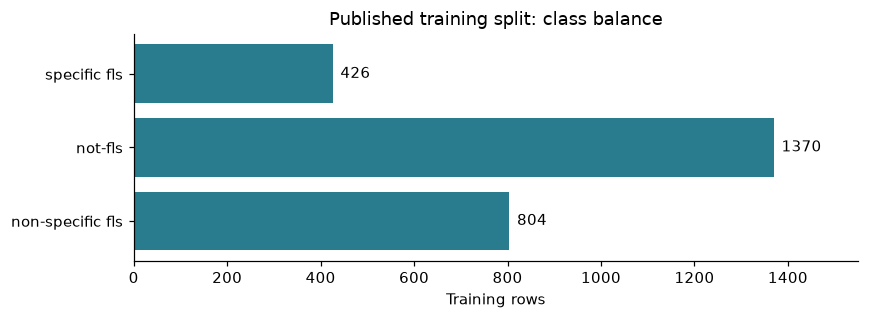

In [5]:
class_table = pd.DataFrame(
    [
        {"label": label, "label_text": name, "rows": report.class_counts[label]}
        for label, name in LABEL_NAMES.items()
    ]
).set_index("label")
class_table["percent"] = 100 * class_table["rows"] / report.row_count
display(class_table.round(2))

fig, ax = plt.subplots(figsize=(8, 3))
bars = ax.barh(class_table["label_text"], class_table["rows"], color="#287c8e")
ax.bar_label(bars, padding=5)
ax.set(
    xlabel="Training rows",
    title="Published training split: class balance",
    xlim=(0, 1550),
)
ax.invert_yaxis()
fig.tight_layout()
plt.show()

## Text length and unusual records

Count characters and whitespace-separated tokens as inexpensive length proxies.
These are **not model tokenizer lengths**. Vocabulary fitting and a truncation
policy will use the future development training partition, after splitting.

,characters,whitespace_tokens
count,2600.00,2600.00
mean,190.49,29.38
std,109.24,16.53
min,29.00,6.00
50%,169.50,26.00
90%,307.10,48.00
95%,367.00,55.05
99%,504.03,77.00
max,2210.00,348.00


characters       whitespace_tokens     
                     median   max            median  max
label_text                                              
non-specific fls      170.0  1213              26.0  171
not-fls               169.5  2210              26.0  348
specific fls          169.0   657              26.0  114

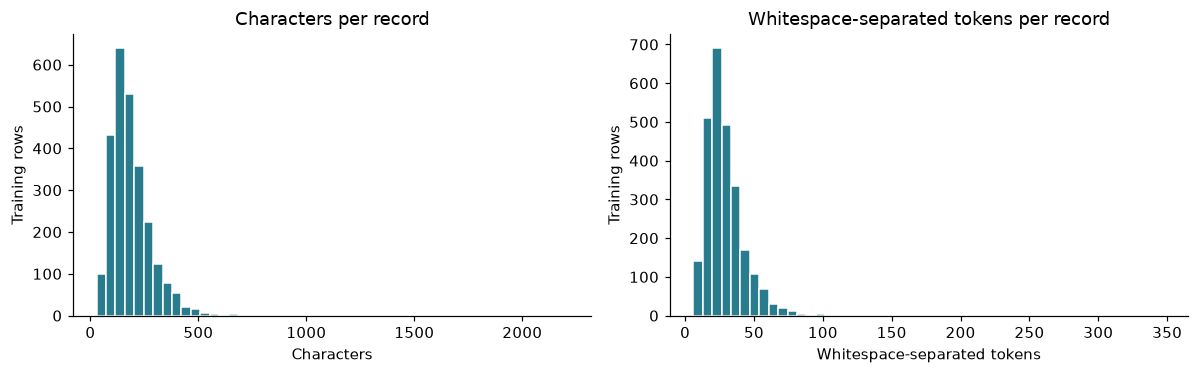

,source_row,label_text,characters,whitespace_tokens,text
2539,2539,not-fls,29,6,No hearing date has been set.
1285,1285,not-fls,2210,348,"In December 2013, Gevo, Inc. entered into additional amendments to certain of its existing agreements with TriplePoint and entered into a new intellectual property assignment agreement in favor of TriplePoint to, among other things: · permit the issuance of Warrants associated with our December 2013 offering of common stock units; · grant TriplePoint a lien and security interest in all of the intellectual property of the Company; · expand the events of default to add as an event of default the repurchase of the Warrants; · waive any prepayment premium (but not any end-of-term payment) with respect to the Original Agri-Energy Loan Agreement and the Amended Agri-Energy Loan Agreement; · re-price the three outstanding warrants to purchase common stock of the Company that are held by TriplePoint, which as of December 31, 2013 are exercisable in the aggregate for 388,411 shares of the Company’s common stock, to reflect an exercise price equal to $1.18 per share; · waive the requirement for Agri-Energy to make principal amortization payments on the Amended Agri-Energy Loan Agreement during the Restructure Period; · raise the interest rates under the Amended Agri-Energy Loan Agreement to 13% during the Restructure Period (provided that such rate will return to 11% following the Restructure Period so long as no event of default under the Amended Agri-Energy Loan Agreement shall be continuing on the last day of the Restructure Period); · during the period beginning January 2015, and continuing through and including the final monthly installment due under the Amended Agri-Energy Loan Agreement, adjust the monthly payment due and payable to 50% of the fully amortizing amount of principal and interest otherwise due and payable for such month, applied first to outstanding accrued interest and then to principal, with the remaining 50% portion of such required payments of principal and interest for such month accruing and made due and payable at the time of the final monthly installment; and · permit dividends and distributions to make cash payments in lieu of issuing fractional shares in connection with any issuance of stock resulting from the exercise of any warrant."


In [6]:
lengths = frame.assign(
    characters=frame["text"].str.len(),
    whitespace_tokens=frame["text"].str.split().str.len(),
)
length_columns = ["characters", "whitespace_tokens"]
display(lengths[length_columns].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).round(2))
display(lengths.groupby("label_text")[length_columns].agg(["median", "max"]))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, column, label in zip(
    axes, length_columns, ["Characters", "Whitespace-separated tokens"], strict=True
):
    ax.hist(lengths[column], bins=50, color="#287c8e", edgecolor="white")
    ax.set(xlabel=label, ylabel="Training rows", title=f"{label} per record")
fig.tight_layout()
plt.show()

extreme_rows = [lengths["characters"].idxmin(), lengths["characters"].idxmax()]
with pd.option_context("display.max_colwidth", None):
    display(
        lengths.loc[extreme_rows, ["source_row", "label_text", *length_columns, "text"]]
    )

The median record has 26 whitespace-separated tokens and the 99th percentile is
77. The longest record (row 1285) has 348: it contains a long enumerated loan
amendment rather than a simple sentence. Inspect such records before deciding
whether to retain, segment, or truncate them; length alone does not establish an error.

## Duplicates and conflicting labels

Exact duplicates compare the original string. Normalized duplicates apply only
Unicode NFC and whitespace collapsing; case, punctuation, dates, and numbers remain
unchanged. The normalized result **includes** exact duplicates, so their counts
must not be added together. Repeated occurrences count all but the first row in each group.

In [7]:
duplicate_sets = {
    "exact": report.exact_duplicates,
    "NFC + whitespace": report.normalized_duplicates,
}
display(
    pd.DataFrame(
        [
            {
                "comparison": name,
                "groups": len(groups),
                "rows_in_groups": sum(len(group.rows) for group in groups),
                "repeated_occurrences": sum(len(group.rows) - 1 for group in groups),
                "conflicting_groups": sum(group.has_label_conflict for group in groups),
            }
            for name, groups in duplicate_sets.items()
        ]
    ).set_index("comparison")
)

display(
    pd.DataFrame(
        [
            {
                "source_rows": group.rows,
                "labels": group.labels,
                "label_conflict": group.has_label_conflict,
            }
            for group in report.normalized_duplicates
        ]
    )
)
conflict_rows = sorted(
    {
        row
        for group in report.normalized_duplicates
        if group.has_label_conflict
        for row in group.rows
    }
)
with pd.option_context("display.max_colwidth", None):
    display(frame.loc[conflict_rows, ["source_row", "label", "label_text", "text"]])

,groups,rows_in_groups,repeated_occurrences,conflicting_groups
comparison,,,,
exact,8,17,9,1
NFC + whitespace,8,17,9,1


,source_rows,labels,label_conflict
0,"(618, 1136, 2557)","(1, 2)",True
1,"(3, 1661)","(1,)",False
2,"(118, 872)","(2,)",False
3,"(311, 2563)","(1,)",False
4,"(406, 1277)","(2,)",False
5,"(682, 2403)","(2,)",False
6,"(1541, 1796)","(2,)",False
7,"(2312, 2341)","(2,)",False


,source_row,label,label_text,text
618,618,1,not-fls,"We base our estimates on historical experience and on various other assumptions that we believe to be reasonable under the circumstances, the results of which form the basis for making judgments about the carrying values of assets and liabilities that are not readily apparent from other sources."
1136,1136,2,non-specific fls,"We base our estimates on historical experience and on various other assumptions that we believe to be reasonable under the circumstances, the results of which form the basis for making judgments about the carrying values of assets and liabilities that are not readily apparent from other sources."
2557,2557,2,non-specific fls,"We base our estimates on historical experience and on various other assumptions that we believe to be reasonable under the circumstances, the results of which form the basis for making judgments about the carrying values of assets and liabilities that are not readily apparent from other sources."


Eight exact duplicate groups involve 17 rows (nine repeated occurrences). NFC and
whitespace normalization find no additional groups. Rows 618, 1136, and 2557 have
identical text but labels `not-fls`, `non-specific fls`, and `non-specific fls`.
The text itself cannot distinguish these targets. Flag this group for adjudication;
majority voting is not evidence that a label is correct.

### Similar-text candidates

As an exploratory check, compare sets of whitespace-separated tokens with Jaccard
similarity (intersection divided by union), using a threshold of 0.90. Exclude pairs
already identical after normalization. This small-corpus, quadratic scan only finds
candidates: it ignores word order and token frequency and can miss paraphrases.
A high score does not establish semantic equivalence, especially around negation
or changed numbers. The threshold is a review setting, not a deduplication rule.

In [8]:
SIMILARITY_THRESHOLD = 0.90
keys = frame["text"].map(normalize_duplicate_text).tolist()
token_sets = [set(key.split()) for key in keys]
candidate_pairs = []
for left, right in combinations(range(len(keys)), 2):
    a, b = token_sets[left], token_sets[right]
    if keys[left] == keys[right] or not a or not b:
        continue
    # This size ratio is an upper bound on Jaccard similarity.
    if min(len(a), len(b)) / max(len(a), len(b)) < SIMILARITY_THRESHOLD:
        continue
    intersection = len(a & b)
    similarity = intersection / (len(a) + len(b) - intersection)
    if similarity >= SIMILARITY_THRESHOLD:
        candidate_pairs.append(
            {
                "left_row": left,
                "right_row": right,
                "similarity": similarity,
                "different_labels": frame.at[left, "label"] != frame.at[right, "label"],
            }
        )

candidates = pd.DataFrame(
    candidate_pairs, columns=["left_row", "right_row", "similarity", "different_labels"]
).sort_values(["similarity", "left_row", "right_row"], ascending=[False, True, True])
print(f"Candidate pairs: {len(candidates)}")
print(f"Pairs with different labels: {candidates['different_labels'].sum()}")
display(candidates.round(3))
if not candidates.empty:
    example_rows = candidates.iloc[0][["left_row", "right_row"]].astype(int).tolist()
    with pd.option_context("display.max_colwidth", None):
        display(frame.loc[example_rows, ["source_row", "label_text", "text"]])

Candidate pairs: 12
Pairs with different labels: 4


,left_row,right_row,similarity,different_labels
3,618,1410,0.949,False
7,1136,1410,0.949,True
9,1410,2557,0.949,True
4,618,1616,0.925,True
8,1136,1616,0.925,False
11,1616,2557,0.925,False
1,118,1541,0.923,False
2,118,1796,0.923,False
5,872,1541,0.923,False
6,872,1796,0.923,False


,source_row,label_text,text
618,618,not-fls,"We base our estimates on historical experience and on various other assumptions that we believe to be reasonable under the circumstances, the results of which form the basis for making judgments about the carrying values of assets and liabilities that are not readily apparent from other sources."
1410,1410,not-fls,"We base our estimates on historical experience and on various other assumptions that we believe are reasonable under the circumstances, the results of which form the basis for making judgments about the carrying values of assets and liabilities that are not readily apparent from other sources."


There are 12 candidate pairs, four with different labels; pair counts are not
counts of distinct groups. The first pair differs by "to be reasonable" versus
"are reasonable". These repeated templates deserve review when defining groups
for development splitting. No near-duplicate groups are merged here.

## Qualitative review

Inspect eight examples per class with a fixed seed. This deliberately balanced
24-row sample helps compare annotation boundaries; it does not estimate label
error rates. It is separate from the targeted duplicate and outlier examples above.

In [9]:
review_sample = (
    frame.groupby("label", group_keys=False, sort=True)
    .sample(n=8, random_state=SEED)
    .sort_values(["label", "source_row"])
)
with pd.option_context("display.max_colwidth", None, "display.max_rows", 30):
    display(review_sample[["source_row", "label_text", "text"]])

,source_row,label_text,text
582,582,specific fls,"The dividend for the first quarter of 2019 will be paid to holders of record on March 8, 2019."
943,943,specific fls,"Cash tax payments in the U.S. are expected to be minimal for the next few years as the Company has $107.4 million of U.S. federal net operating loss carryforwards, $112.4 million of state and local net operating loss carryforwards, $0.2 million of foreign tax credit carryforwards, and $0.4 million of AMT credit carryforwards."
1012,1012,specific fls,"In our major origins, we project somewhat smaller crops to be marketed in Brazil in fiscal year 2010, which should keep flue-cured markets in relative balance."
1772,1772,specific fls,"The combustion turbine generators which the Company has committed to purchase (see ""Capital Program and Financing"" section above) will be fueled by natural gas."
2159,2159,specific fls,The swaps mature over the next two years.
2256,2256,specific fls,"Under a standing authorization from our board of directors, we may purchase an additional 3.4 million shares in the open market or in privately negotiated transactions at prices management deems appropriate."
2421,2421,specific fls,"In 2006, the Company expects to realize the cost savings associated with the restructuring actions taken in 2005, primarily through reduced employee and facility costs."
2523,2523,specific fls,We believe that our purchases from Medisystems have been on terms no less favorable to us than could be obtained from unaffiliated third parties or through internal operations.
40,40,not-fls,We ended 2015 with available liquidity of $2.6 billion which is comprised of unrestricted cash of $156.7 million and undrawn balances under our warehouse facility and unsecured revolving credit facility of $2.4 billion.
520,520,not-fls,"Pursuant to GAAP, contracts not designated as normal purchases or normal sales are required to be accounted for as derivatives with changes in fair value (representing unrealized gains or losses) recognized in earnings in the periods prior to physical delivery."


Observations from this sample:

- Row 2159 ("The swaps mature over the next two years.") is specific FLS without
  a future auxiliary. Row 2256 uses "may purchase" for a company-specific action.
  Keyword rules alone will miss these distinctions.
- Row 2335 describes the status of forward-looking statements and is labeled
  `not-fls`. Mentioning future events does not necessarily make the sentence a prediction.
- Row 751 (a business plan calling for increased originations, `not-fls`) and row
  2523 (a retrospective belief about purchase terms, `specific fls`) merit a closer
  annotation review. Row 989's company plan is labeled `non-specific fls`, another
  useful boundary case. These observations do not establish replacement labels.

## Implications for preparation

- Preserve the pinned source and carry `source_row` into derived records. The
  2,600 training rows pass structural and label-mapping checks.
- Review the 135 Unicode warnings and the conflicting three-row duplicate group
  before specifying cleaning and exclusion rules. Record any decisions explicitly.
- Keep duplicate groups together when forming development train/validation splits;
  review similar-text candidates before extending grouping beyond exact matches.
- Use a stratification strategy compatible with those groups. Fit vocabulary and
  choose tokenizer length limits on the development training partition only.

No cleaned dataset or development partitions are produced in this step. There are
no company, document, or date identifiers available for grouping. Published
train/test overlap has not been checked here; a later automated check can report
aggregate overlap without exposing test text or labels to exploration. This audit
does not establish that the published test split is free of leakage.

In [10]:
assert hashlib.sha256(train_path.read_bytes()).hexdigest() == train_sha256
assert len(frame) == report.row_count
print("Audit complete. Training source checksum unchanged; no test rows loaded.")

Audit complete. Training source checksum unchanged; no test rows loaded.
